## Loading the Packages:

In [1]:
import os
import torch
import time
import random
import warnings
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import matplotlib.cm as cm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from sklearn.metrics import mean_squared_error
from data import load_from_path, ReDataset, exact_solution, get_dt

## Loading the data:

In [2]:
# loading the intervals - 
data_path = "./data"
dataset_train, dataset_val, re_interval_split, _ = load_from_path(data_path)

# Interval Split
print("Re Interval Split: \n", re_interval_split)

Re Interval Split: 
 IntervalSplit(interpolation=[1006.1101523265738, 1206.1101523265738], extrapolation_left=[400, 600.0], extrapolation_right=[2200.0, 2400])


## Loading the Evolution Operator:

In [3]:
from model_io import load_model
from model_v2 import Encoder, Decoder, Propagator_concat as Propagator_C, Model as LEO_Model

In [4]:
evol_op_path = "./LEO_fixed_IC.pt"

def get_model(input_dim, latent_dim, Propagator):
    # Instantiate encoder, decoder, and model
    encoder = Encoder(input_dim, latent_dim)
    decoder = Decoder(latent_dim, input_dim)  # Decoder for x(t)
    propagator = Propagator(latent_dim)  # z(t) --> z(t+tau)
    model = LEO_Model(encoder, decoder, propagator)
    return model

def load_model_weights(model, checkpoint_path):
    """
    Loads the checkpoint from the given path, extracts the model_state_dict
    (if it exists), and loads it into the model using strict=False.
    """
    if not os.path.isfile(checkpoint_path):
        print(f"Checkpoint file not found at path: {checkpoint_path}")
        return model
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    except Exception as e:
        print(f"Error loading checkpoint from {checkpoint_path}: {e}")
        return model
    
    # If the checkpoint has a key "model_state_dict", extract it.
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

# # Loading the best Model:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = get_model(128, 2, Propagator_C)
model = load_model_weights(model, evol_op_path).to(device)
model_ev_op = model

### Validating Evol Operator:

MSE Recon 9.313048e-05
MSE Pred 5.945459e-07


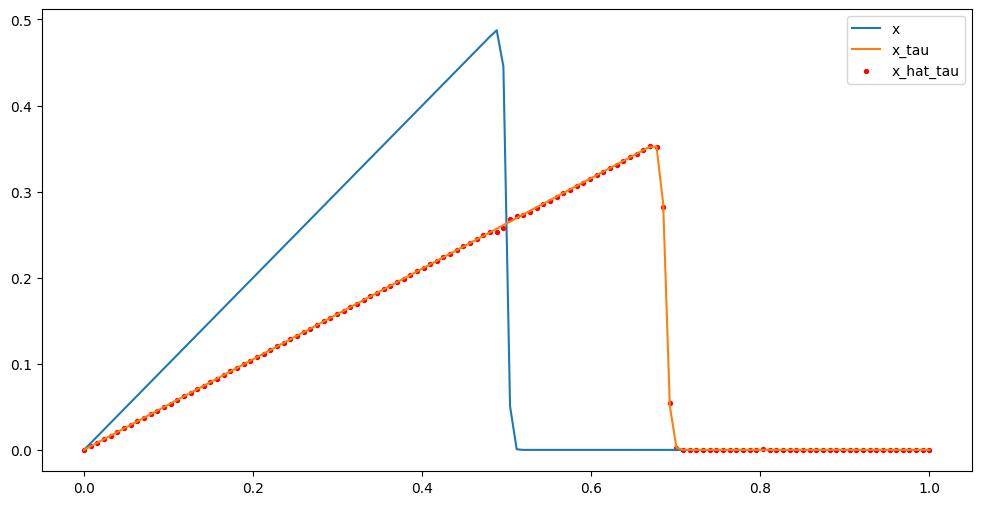

In [5]:
mx , dt = 128, 0.004
x_space = np.linspace(0.0, 1.0, num=mx)

def get_data_loader(dataset, batch_size):
    data = list(zip(dataset.X, dataset.X_tau, dataset.t_values, dataset.tau_values, dataset.Re_values))
    data = data[: len(data) - len(data) % batch_size]
    return DataLoader(data, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = get_data_loader(dataset_val, batch_size = 256)

for batch in test_loader:
    batch: torch.Tensor
    x, x_tau, t, tau, re = batch
    x, x_tau, t, tau, re = x.cuda().float().unsqueeze(1), x_tau.cuda().float().unsqueeze(1), t.cuda().float().unsqueeze(1), tau.cuda().float().unsqueeze(1), re.cuda().float().unsqueeze(1)
    x_hat, x_hat_tau, mean, log_var, z_tau = model_ev_op(x, tau, re)

    n = np.random.randint(0, x.shape[0])
    plt.figure(figsize = (12, 6))
    plt.plot(x_space, x[n, :].cpu().squeeze().numpy(), label = "x")
    #plt.scatter(x_space, x_hat[n, :].cpu().detach().squeeze().numpy(), label = "x_hat", s = 8, c = "orange")
    plt.plot(x_space, x_tau[n, :].cpu().squeeze().numpy(), label = "x_tau")
    plt.scatter(x_space, x_hat_tau[n, :].cpu().detach().squeeze().numpy(), label = "x_hat_tau", s = 8, c = "red")
    print("MSE Recon", mean_squared_error(x[n, :].cpu().squeeze().numpy(), x_hat[n, :].cpu().detach().squeeze().numpy()))
    print("MSE Pred", mean_squared_error(x_tau[n, :].cpu().squeeze().numpy(), x_hat_tau[n, :].cpu().detach().squeeze().numpy()))
    plt.legend() 

    break

MSE Recon 0.00017107271362031364
MSE Pred 1.7732632907524436e-06


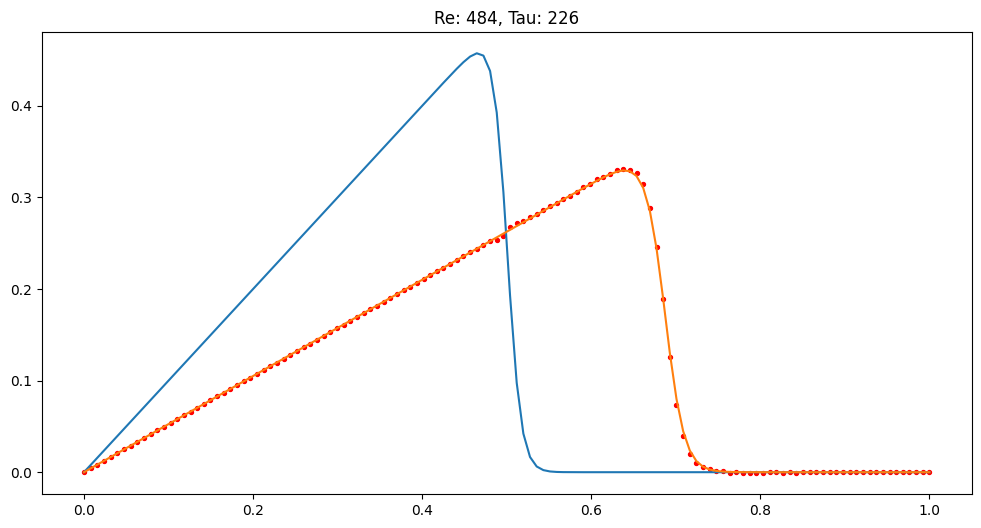

In [6]:
re, t_0 = np.random.randint(400, 600), 0 # IC is fixed at 0
tau = np.random.randint(1, 500)

t_end = t_0 + tau*dt
ic = exact_solution(re, t_0)
x_tau = exact_solution(re, t_end)

x_hat, x_hat_tau, mu, log_var, z_tau = model_ev_op(torch.tensor(ic, dtype = torch.float32)[None, None, :].to(device),
                                            torch.tensor(tau, dtype = torch.float32)[None, None].to(device),
                                            torch.tensor(re, dtype = torch.float32)[None, None].to(device))

plt.figure(figsize = (12, 6))
plt.plot(x_space, ic, label = "x")
#plt.scatter(x_space, x_hat.cpu().detach().squeeze().numpy(), label = "x_hat", s = 8, c = "orange")
plt.plot(x_space, x_tau, label = "x_tau")
plt.scatter(x_space, x_hat_tau.cpu().detach().squeeze().numpy(), label = "x_hat_tau", s = 8, c = "red")

plt.title(f"Re: {re}, Tau: {tau}")
print("MSE Recon", mean_squared_error(ic, x_hat.cpu().detach().squeeze().numpy()))
print("MSE Pred", mean_squared_error(x_tau, x_hat_tau.cpu().detach().squeeze().numpy()))

## Loading L-DON

In [7]:
# L-DON tensors
branch_train = torch.tensor(dataset_train.X,        dtype=torch.float32)            # [N, 128]
trunk_train  = torch.tensor(dataset_train.tau_values * dt, dtype=torch.float32)     # [N,] (time)
target_train = torch.tensor(dataset_train.X_tau,    dtype=torch.float32)            # [N, 128]
re_train     = torch.tensor(dataset_train.Re_values,dtype=torch.float32)            # [N,]

branch_test  = torch.tensor(dataset_val.X,          dtype=torch.float32)
trunk_test   = torch.tensor(dataset_val.tau_values * dt, dtype=torch.float32)
target_test  = torch.tensor(dataset_val.X_tau,      dtype=torch.float32)
re_test      = torch.tensor(dataset_val.Re_values,  dtype=torch.float32)


# Normalize q (time)
q_mu = trunk_train.mean()
q_sd = trunk_train.std().clamp_min(1e-8)
trunk_train_n = (trunk_train - q_mu) / q_sd
trunk_test_n  = (trunk_test  - q_mu) / q_sd

In [8]:
from helper_LDON import *

In [9]:
# Loading the AutoEncoder Model:
enc = Encoder(input_dim=128)
dec = Decoder(latent_dim=2, output_dim=128)
model = Model(enc, dec)
enc, dec, model = enc.to(device), dec.to(device), model.to(device)

# Loading best AE weights
ae_load_path = "./best_AE_LDON.pt"
ckpt = torch.load(ae_load_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

# Loading the trunk and branch net:
m, p = 2, 16
branch = BranchMLP(in_dim=m, m=m, p=p, hidden=(128, 256)).to(device)
trunk  = TrunkMLP(loc_dim=1, m=m, p=p, hidden=(100, 100)).to(device)

# Loading best weights for trunk and branch:
load_path_l_don = "./best_LDON.pt"
ckpt = torch.load(load_path_l_don, map_location=device)
branch.load_state_dict(ckpt["branch"])
trunk.load_state_dict(ckpt["trunk"])
branch = branch.to(device); trunk = trunk.to(device)

# keep these for inference later if needed
q_mu_loaded = ckpt["q_mu"]
q_sd_loaded = ckpt["q_sd"]

In [10]:
# small helper: forward to latent at q
def forward_latent(u128, q_n):
    """Predict latent at q (already normalized)."""
    with torch.no_grad():
        z0 = enc(u128)           # [B, m]
    yb = branch(z0)                  # [B, m, p]
    yt = trunk(q_n)                  # [B, m, p]
    Z_pred = torch.einsum('bmp,bmp->bm', yb, yt)  # [B, m]
    return Z_pred

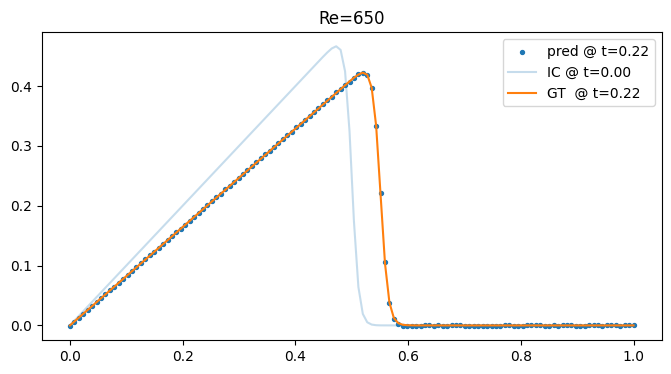

In [11]:
def validation(re_val, device, *, t_mu, t_sd):
    """
    Re_val: scalar Reynolds number (float)
    Returns:
      pred (128,), ic (128,), exact(128,), ic_time (float), query_time (float)
    """
    # sample IC time shift (delta) and a random index into t_range
    idx   = np.random.randint(0, len(t_range))
    delta = np.random.uniform(0.00, 0.0001)          # IC drawn from [0, 2)
    t_q   = t_range[idx] + delta                  # query time

    # keep query time inside [0, 2.0)
    if t_q > 2.0:
        raise ValueError(f"Could not produce valid query time in [0,2.0): got {t_q:.4f}")
    else:
        # initial condition at time = delta
        ic_np = exact_solution(re_val, float(delta))               # (128,)
        ic    = torch.tensor(ic_np, dtype=torch.float32, device=device)[None, :]  # [1,128]
    
        # normalize time exactly like training: q_norm = (t_q - t_mu) / t_sd
        t_q_tensor = torch.tensor([t_q], dtype=torch.float32, device=device)      # [1]
        q_norm     = (t_q_tensor - t_mu) / (t_sd + 1e-8)
        q_norm     = q_norm[:, None]                                              # [1,1]
    
        # predict latent at q_norm, decode to high-dim
        z_pred = forward_latent(ic, q_norm)            # [1, m]
        pred   = dec(z_pred).squeeze(0).detach().cpu().numpy()  # (128,)
    
        # exact state at query time
        exact_np = exact_solution(re_val, float(t_q))  # (128,)

    return pred, ic_np, exact_np, float(delta), float(t_q)

# Build time grid (updated domain)
num_time_steps = 500
def get_dt(n): return 2.0 / n
t_0, t_end = 0.00, 2.00
dt = get_dt(num_time_steps)
t_range = np.arange(t_0, t_end, dt)  # [0,2.0)

# Run a sample validation (only t normalized)
pred, ic, exact_sol, ic_time, query_time = validation(
    re_val=650,
    device=device,
    t_mu=q_mu_loaded,   # training mean of (raw) time
    t_sd=q_sd_loaded    # training std  of (raw) time
)

plt.figure(figsize=(8,4))
plt.scatter(x_space, pred, s=8, label=f"pred @ t={query_time:.2f}")
plt.plot(x_space, ic,            alpha=0.25, label=f"IC @ t={ic_time:.2f}")
plt.plot(x_space, exact_sol,                 label=f"GT  @ t={query_time:.2f}")
plt.title("Re=650")
plt.legend(); plt.show()

# Trial

In [12]:
@torch.no_grad()
def predict_ldon_curve(enc, branch, trunk, dec, forward_latent, t_f, ic_vec, t_mu, t_sd, device):
    """
    L-DON predicts a full curve from the latent (no per-x trunk).
    returns: (mx,)
    """
    ic = torch.tensor(ic_vec[None, :], dtype=torch.float32, device=device)  # [1,128]
    t_q = torch.tensor([t_f], dtype=torch.float32, device=device)           # [1]
    q_norm = ((t_q - t_mu) / (t_sd + 1e-8))[:, None]                        # [1,1]
    z_pred = forward_latent(ic, q_norm)                                     # [1, m]
    pred   = dec(z_pred).squeeze(0).detach().cpu().numpy().astype(np.float32)  # (mx,)
    return pred

@torch.no_grad()
def predict_evo_curve(model_ev_op, Re_val, tau_steps, ic_vec):
    """
    Your Operator-Evolution model uses (ic, tau, Re).
    returns: (mx,)
    """
    if tau_steps < 1:
        return None
    device = next(model_ev_op.parameters()).device
    ic_t  = torch.tensor(ic_vec[None, None, :], dtype=torch.float32, device=device)  # [1,1,128]
    tau_t = torch.tensor(tau_steps, dtype=torch.float32, device=device)[None, None]  # [1,1]
    re_t  = torch.tensor(Re_val,    dtype=torch.float32, device=device)[None, None]  # [1,1]
    x_hat, x_hat_tau, _, _, _ = model_ev_op(ic_t, tau_t, re_t)
    return x_hat_tau.squeeze(0).squeeze(0).detach().cpu().numpy().astype(np.float32) # (mx,)

Re_try = np.random.randint(400, 600)
t_init = np.random.uniform(0.2, 0.75)        # IC time
# sample τ until t_f < 2.0
for _ in range(10):
    tau = np.random.randint(150, 425)          # [1,500]
    t_f = t_init + tau * dt
    if t_f < 2.0:
        break
else:
    raise RuntimeError("Failed to sample a valid τ with t_f < 2.0 after several tries.")

# IC and exact
ic_vec   = exact_solution(Re_try, t_init).astype(np.float32)   # (mx,)
true_vec = exact_solution(Re_try, t_f).astype(np.float32)      # (mx,)

# Predictions
#net.eval()
#don_vec  = predict_don_curve(net, Re_try, t_f, ic_vec, mu, sd)                 # (mx,)
device_L = next(branch.parameters()).device  # any L-DON module's device
ldon_vec = predict_ldon_curve(enc, branch, trunk, dec, forward_latent,
                              t_f, ic_vec, q_mu_loaded, q_sd_loaded, device_L) # (mx,)
model_ev_op.eval()
evo_vec  = predict_evo_curve(model_ev_op, Re_try, tau, ic_vec)                 # (mx,)

In [13]:
@torch.no_grad()
def evaluate_models_fixed_t0(num_samples_per_t=250):
    re_intervals = {
        "low_Re": re_interval_split.extrapolation_left,
        "medium_Re": re_interval_split.interpolation,
        "high_Re": re_interval_split.extrapolation_right
    }

    results = {
        region: {
            'mse_ldon_mean': 0,
            'mse_ldon_std': 0,
            'mse_evo_mean': 0,
            'mse_evo_std': 0,
            'all_mse_ldon': [],
            'all_mse_evo': []
        } for region in re_intervals.keys()
    }

    model_ev_op.eval()

    t_init = 0
    tau_low = 1
    tau_high = 500

    print(f"Evaluating at fixed t_init={t_init} with tau range [{tau_low}, {tau_high}]")
    print(f"dt = {dt}")

    print("\nTesting data generation...")
    test_re = 1000
    test_tau = 100
    test_t_f = t_init + test_tau * dt
    print(f"Test: Re={test_re}, tau={test_tau}, t_f={test_t_f}")

    try:
        test_ic = exact_solution(test_re, t_init).astype(np.float32)
        test_true = exact_solution(test_re, test_t_f).astype(np.float32)
        print(f"✓ Data generation works: IC shape={test_ic.shape}, range=[{test_ic.min():.3f}, {test_ic.max():.3f}]")
        print(f"  True shape={test_true.shape}, range=[{test_true.min():.3f}, {test_true.max():.3f}]")
    except Exception as e:
        print(f"✗ Data generation failed: {e}")
        return results

    print("\nTesting individual models...")

    try:
        ldon_components = [enc, branch, trunk, dec, forward_latent]
        ldon_names = ['enc', 'branch', 'trunk', 'dec', 'forward_latent']
        all_ldon_ok = True
        for comp, name in zip(ldon_components, ldon_names):
            if comp is None:
                print(f"✗ L-DON component {name} is None")
                all_ldon_ok = False

        if all_ldon_ok:
            test_ldon = predict_ldon_curve(
                enc, branch, trunk, dec, forward_latent,
                test_t_f, test_ic, q_mu_loaded, q_sd_loaded, device_L
            )
            print(f"✓ L-DON works: shape={test_ldon.shape}, range=[{test_ldon.min():.3f}, {test_ldon.max():.3f}]")
        else:
            print("✗ L-DON components missing")
    except Exception as e:
        print(f"✗ L-DON failed: {e}")

    try:
        if evol_op is None:
            print("✗ Evolution operator is None")
        else:
            test_evo = predict_evo_curve(model_ev_op, test_re, test_tau, test_ic)
            print(f"✓ Evolution operator works: shape={test_evo.shape}, range=[{test_evo.min():.3f}, {test_evo.max():.3f}]")
    except Exception as e:
        print(f"✗ Evolution operator failed: {e}")

    print("\nStarting main evaluation...")

    for region_name, (re_low, re_high) in re_intervals.items():
        print(f"\nProcessing region: {region_name} (Re: {re_low}-{re_high})")

        mse_ldon_list, mse_evo_list = [], []

        valid_samples = 0
        total_attempts = 0
        max_total_attempts = num_samples_per_t * 10
        error_count = 0
        max_errors_to_print = 5

        while valid_samples < num_samples_per_t and total_attempts < max_total_attempts:
            total_attempts += 1

            Re_try = np.random.randint(re_low, re_high)
            tau = np.random.randint(tau_low, tau_high)
            t_f = t_init + tau * dt

            if t_f >= 2.0:
                continue

            ic_vec = exact_solution(Re_try, t_init).astype(np.float32)
            true_vec = exact_solution(Re_try, t_f).astype(np.float32)

            try:
                ldon_vec = predict_ldon_curve(
                    enc, branch, trunk, dec, forward_latent,
                    t_f, ic_vec, q_mu_loaded, q_sd_loaded, device_L
                )
                mse_ldon = mean_squared_error(true_vec, ldon_vec)
                mse_ldon_list.append(mse_ldon)

                evo_vec = predict_evo_curve(model_ev_op, Re_try, tau, ic_vec)
                if evo_vec is not None:
                    mse_evo = mean_squared_error(true_vec, evo_vec)
                    mse_evo_list.append(mse_evo)
                else:
                    continue

                valid_samples += 1

                if valid_samples % 50 == 0:
                    print(f"  Collected {valid_samples}/{num_samples_per_t} samples")

            except Exception as e:
                error_count += 1
                if error_count <= max_errors_to_print:
                    print(f"  Error in sample {total_attempts}: {e}")
                    print(f"    Re={Re_try}, tau={tau}, t_f={t_f:.3f}")
                continue

        if mse_ldon_list and mse_evo_list:
            results[region_name]['mse_ldon_mean'] = np.mean(mse_ldon_list)
            results[region_name]['mse_ldon_std'] = np.std(mse_ldon_list)
            results[region_name]['mse_evo_mean'] = np.mean(mse_evo_list)
            results[region_name]['mse_evo_std'] = np.std(mse_evo_list)
            results[region_name]['all_mse_ldon'] = mse_ldon_list
            results[region_name]['all_mse_evo'] = mse_evo_list

            print(f"  ✓ Successfully collected {valid_samples} samples")
            print(f"    Attempts: {total_attempts}, Success rate: {valid_samples/total_attempts*100:.1f}%")
            print(f"    Mean MSE: L-DON={results[region_name]['mse_ldon_mean']:.2e}, "
                  f"Evo-Op={results[region_name]['mse_evo_mean']:.2e}")
        else:
            print(f"  ✗ Insufficient samples for {region_name}")
            print(f"    Valid samples: {valid_samples}, Total attempts: {total_attempts}")
            if error_count > 0:
                print(f"    Total errors encountered: {error_count}")

    return results


def get_re_range(region_name):
    re_intervals = {
        "low_Re": re_interval_split.extrapolation_left,
        "medium_Re": re_interval_split.interpolation,
        "high_Re": re_interval_split.extrapolation_right
    }
    re_low, re_high = re_intervals[region_name]
    return f"{re_low:.0f}-{re_high:.0f}"

In [14]:
def plot_single_bar_plot_with_std(results, save_path):
    regions = list(results.keys())
    models = ['L-DON', 'Evo-Op']
    colors = ['#ff7f0e', '#2ca02c']

    means = {
        'L-DON': [results[region]['mse_ldon_mean'] for region in regions],
        'Evo-Op': [results[region]['mse_evo_mean'] for region in regions],
    }

    stds = {
        'L-DON': [results[region]['mse_ldon_std'] for region in regions],
        'Evo-Op': [results[region]['mse_evo_std'] for region in regions],
    }

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(regions))
    width = 0.35

    for i, (model, color) in enumerate(zip(models, colors)):
        means_list = means[model]
        stds_list = stds[model]

        label = "D-LEO-VAE" if model == "Evo-Op" else model

        ax.bar(
            x + i * width,
            means_list,
            width,
            label=label,
            alpha=0.8,
            color=color
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([f'{region}\nRe: {get_re_range(region)}' for region in regions])

    all_means = [m for lst in means.values() for m in lst if m > 0]
    y_max = max(all_means)
    y_min = min(all_means)
    ax.set_yscale('log')
    ax.set_ylim(y_min * 0.5, y_max * 5.0)

    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=20, loc='upper right')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")

    plt.show()

In [15]:
def print_comprehensive_statistics(results):
    print("\n" + "=" * 80)
    print("COMPREHENSIVE MODEL COMPARISON AT t=0")
    print("=" * 80)

    print("\nOVERALL SUMMARY:")
    print("-" * 50)

    overall_ldon = np.mean([results[region]['mse_ldon_mean'] for region in results.keys()])
    overall_evo = np.mean([results[region]['mse_evo_mean'] for region in results.keys()])

    overall_improvement = (overall_ldon - overall_evo) / overall_ldon * 100
    print("Average across all regions:")
    print(f"  L-DON:     {overall_ldon:.2e}")
    print(f"  D-LEO-VAE: {overall_evo:.2e}")
    print(f"  → D-LEO-VAE overall improvement vs L-DON: {overall_improvement:+.1f}%")

    for region in results.keys():
        if results[region]['all_mse_ldon'] and results[region]['all_mse_evo']:
            ldon_mean = results[region]['mse_ldon_mean']
            ldon_std = results[region]['mse_ldon_std']
            evo_mean = results[region]['mse_evo_mean']
            evo_std = results[region]['mse_evo_std']

            n_ldon = len(results[region]['all_mse_ldon'])
            n_evo = len(results[region]['all_mse_evo'])
            n = min(n_ldon, n_evo)

            ldon_ci = 1.96 * ldon_std / np.sqrt(n_ldon)
            evo_ci = 1.96 * evo_std / np.sqrt(n_evo)

            improvement_evo_vs_ldon = (ldon_mean - evo_mean) / ldon_mean * 100

            print(f"\n{region.upper()} REGION (Re: {get_re_range(region)}, n≈{n} samples):")
            print(f"  L-DON:     {ldon_mean:.2e} ± {ldon_std:.2e}")
            print(f"             (95% CI: [{ldon_mean-ldon_ci:.2e}, {ldon_mean+ldon_ci:.2e}])")
            print(f"  D-LEO-VAE: {evo_mean:.2e} ± {evo_std:.2e}")
            print(f"             (95% CI: [{evo_mean-evo_ci:.2e}, {evo_mean+evo_ci:.2e}])")

            print("\n  IMPROVEMENT ANALYSIS:")
            print(f"  → D-LEO-VAE vs L-DON: {improvement_evo_vs_ldon:+.1f}% improvement")

            print("\n  STATISTICAL SIGNIFICANCE:")
            if evo_mean + evo_ci < ldon_mean - ldon_ci:
                print("  ✓ D-LEO-VAE is statistically significantly better than L-DON")
            elif ldon_mean + ldon_ci < evo_mean - evo_ci:
                print("  ✓ L-DON is statistically significantly better than D-LEO-VAE")
            else:
                print("  - Difference not statistically significant (by non-overlapping CI check)")

            models_ranking = sorted([
                ('L-DON', ldon_mean),
                ('D-LEO-VAE', evo_mean)
            ], key=lambda x: x[1])

            print(f"  🏆 PERFORMANCE RANKING: {models_ranking[0][0]} > {models_ranking[1][0]}")

In [16]:
# Main execution
print("Starting comprehensive evaluation at fixed t_init=0...")
print(f"Sampling 500 random (Re, τ) pairs for each region")
print(f"τ range: [1, 500], dt = {dt}")
print("Each sample: random Re from region + random τ from range")

results = evaluate_models_fixed_t0(num_samples_per_t = 1000)

Starting comprehensive evaluation at fixed t_init=0...
Sampling 500 random (Re, τ) pairs for each region
τ range: [1, 500], dt = 0.004
Each sample: random Re from region + random τ from range
Evaluating at fixed t_init=0 with tau range [1, 500]
dt = 0.004

Testing data generation...
Test: Re=1000, tau=100, t_f=0.4
✓ Data generation works: IC shape=(128,), range=[0.000, 0.476]
  True shape=(128,), range=[0.000, 0.402]

Testing individual models...
✓ L-DON works: shape=(128,), range=[-0.001, 0.401]
✗ Evolution operator failed: name 'evol_op' is not defined

Starting main evaluation...

Processing region: low_Re (Re: 400-600.0)
  Collected 50/1000 samples
  Collected 100/1000 samples
  Collected 150/1000 samples
  Collected 200/1000 samples
  Collected 250/1000 samples
  Collected 300/1000 samples
  Collected 350/1000 samples
  Collected 400/1000 samples
  Collected 450/1000 samples
  Collected 500/1000 samples
  Collected 550/1000 samples
  Collected 600/1000 samples
  Collected 650/1000


Plotting results...
Figure saved to: /home/krafiq/Desktop/DeepONet/fvae_ic_fixed/Fixed_Ic_Comparison


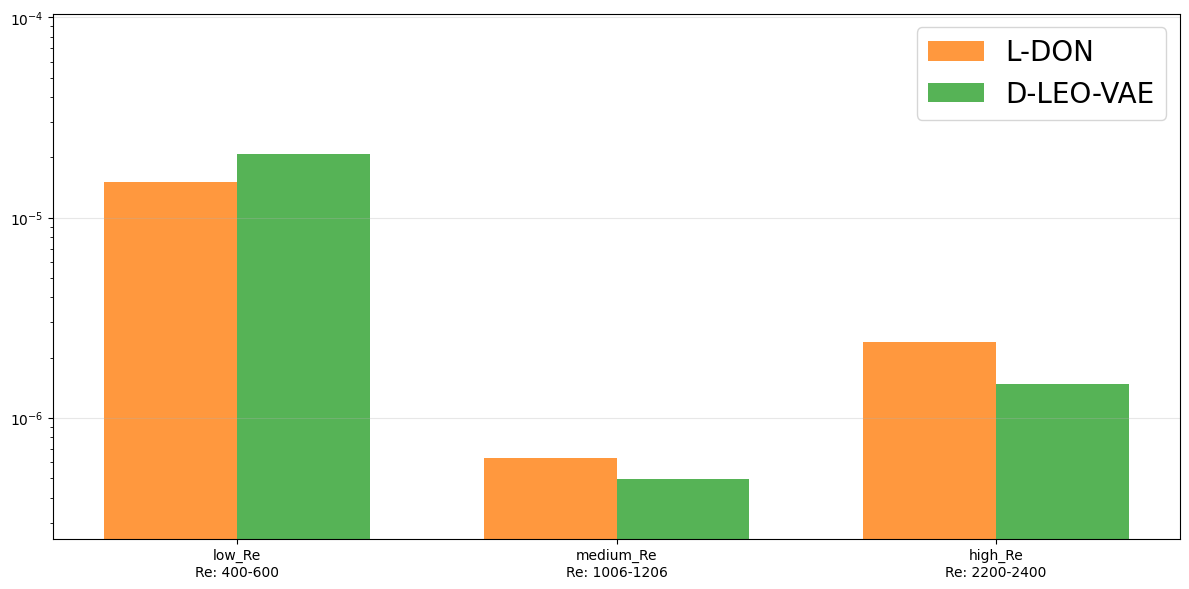


COMPREHENSIVE MODEL COMPARISON AT t=0

OVERALL SUMMARY:
--------------------------------------------------
Average across all regions:
  L-DON:     6.04e-06
  D-LEO-VAE: 7.61e-06
  → D-LEO-VAE overall improvement vs L-DON: -26.1%

LOW_RE REGION (Re: 400-600, n≈1000 samples):
  L-DON:     1.51e-05 ± 1.82e-05
             (95% CI: [1.40e-05, 1.62e-05])
  D-LEO-VAE: 2.09e-05 ± 9.60e-05
             (95% CI: [1.49e-05, 2.68e-05])

  IMPROVEMENT ANALYSIS:
  → D-LEO-VAE vs L-DON: -38.2% improvement

  STATISTICAL SIGNIFICANCE:
  - Difference not statistically significant (by non-overlapping CI check)
  🏆 PERFORMANCE RANKING: L-DON > D-LEO-VAE

MEDIUM_RE REGION (Re: 1006-1206, n≈1000 samples):
  L-DON:     6.30e-07 ± 8.14e-07
             (95% CI: [5.80e-07, 6.81e-07])
  D-LEO-VAE: 4.97e-07 ± 1.06e-07
             (95% CI: [4.90e-07, 5.04e-07])

  IMPROVEMENT ANALYSIS:
  → D-LEO-VAE vs L-DON: +21.1% improvement

  STATISTICAL SIGNIFICANCE:
  ✓ D-LEO-VAE is statistically significantly better 

In [17]:
# Only plot if we have results
regions_with_data = [
    region for region in results.keys()
    if results[region]['all_mse_ldon'] and results[region]['all_mse_evo']
]

if regions_with_data:
    print("\nPlotting results...")
    plot_single_bar_plot_with_std(
        results,
        save_path="/home/krafiq/Desktop/DeepONet/fvae_ic_fixed/Fixed_Ic_Comparison"
    )
    print_comprehensive_statistics(results)
else:
    print("\nNo data collected for any region. Cannot generate plots.")
    print("Please check the error messages above to identify the issue.")

## Varying the Anchor Point (Generalization over t_0)

In [18]:
# Loading the Variable-Anchor Evo-Op model
from model_v2 import Encoder, Decoder, Propagator_concat as Propagator_C, Model as LEO

concat_best_path = "./D_LEO_VAE_Best.pt"

def get_model(input_dim, latent_dim, Propagator):
    encoder = Encoder(input_dim, latent_dim)
    decoder = Decoder(latent_dim, input_dim)
    propagator = Propagator(latent_dim)
    model = LEO(encoder, decoder, propagator)
    return model

def load_model_weights(model, checkpoint_path):
    if not os.path.isfile(checkpoint_path):
        print(f"Checkpoint file not found at path: {checkpoint_path}")
        return model
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    except Exception as e:
        print(f"Error loading checkpoint from {checkpoint_path}: {e}")
        return model
    
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

# Template + load variable-anchor model
concat_model_template = get_model(128, 2, Propagator_C)

best_concat_model = get_model(128, 2, Propagator_C)
best_concat_model = load_model_weights(best_concat_model, concat_best_path)


# Loading multi anchor LEO
evol_op_var = best_concat_model.to(device)

# Fixed anchor point model:
evol_op_fixed = model_ev_op

In [19]:
@torch.no_grad()
def predict_ldon_curve(enc, branch, trunk, dec, forward_latent, t_f, ic_vec, t_mu, t_sd, device):
    """
    L-DON predicts a full curve from the latent (no per-x trunk).
    returns: (mx,)
    """
    ic = torch.tensor(ic_vec[None, :], dtype=torch.float32, device=device)   # [1,128]
    t_q = torch.tensor([t_f], dtype=torch.float32, device=device)             # [1]
    q_norm = ((t_q - t_mu) / (t_sd + 1e-8))[:, None]                          # [1,1]
    z_pred = forward_latent(ic, q_norm)                                       # [1,m]
    pred = dec(z_pred).squeeze(0).detach().cpu().numpy().astype(np.float32)   # (mx,)
    return pred


@torch.no_grad()
def predict_evo_curve(model_ev_op, Re_val, tau_steps, ic_vec):
    """
    Evo-Op model uses (ic, tau, Re).
    returns: (mx,)
    """
    if tau_steps < 1:
        return None
    
    device_m = next(model_ev_op.parameters()).device
    ic_t  = torch.tensor(ic_vec[None, None, :], dtype=torch.float32, device=device_m)  # [1,1,128]
    tau_t = torch.tensor(tau_steps, dtype=torch.float32, device=device_m)[None, None]   # [1,1]
    re_t  = torch.tensor(Re_val,    dtype=torch.float32, device=device_m)[None, None]   # [1,1]

    x_hat, x_hat_tau, _, _, _ = model_ev_op(ic_t, tau_t, re_t)
    return x_hat_tau.squeeze(0).squeeze(0).detach().cpu().numpy().astype(np.float32)    # (mx,)

Re=508 | t_init=0.4545 | tau=252 | t_f=1.4625
  L-DON              MSE: 1.055052e-03
  Evo-Op (fixed IC)  MSE: 5.165221e-03
  Evo-Op (var anchor)MSE: 3.276550e-05


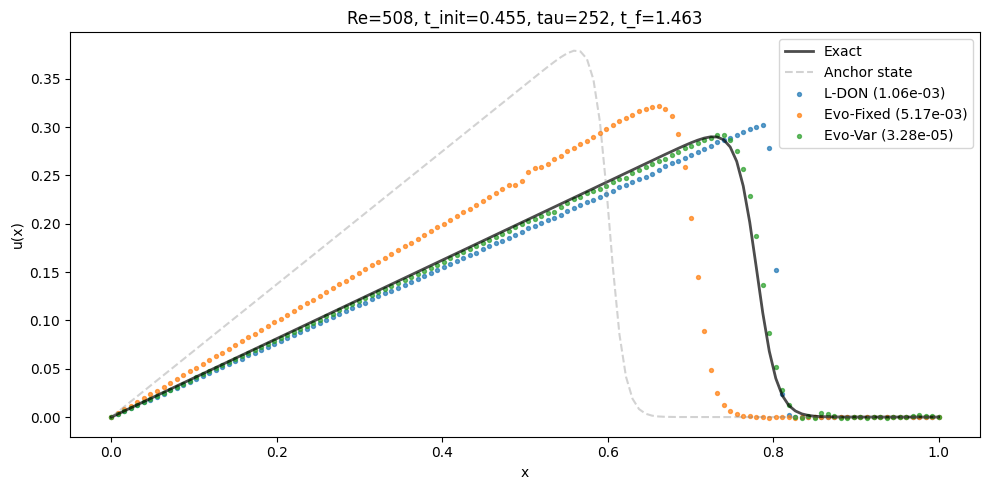

In [20]:
# quick sanity check on one random sample
Re_try = np.random.randint(400, 600)
t_init = np.random.uniform(0.2, 0.75)

# sample tau until t_f < 2.0
for _ in range(10):
    tau = np.random.randint(150, 425)
    t_f = t_init + tau * dt
    if t_f < 2.0:
        break
else:
    raise RuntimeError("Failed to sample a valid tau with t_f < 2.0 after several tries.")

# IC and exact
ic_vec   = exact_solution(Re_try, t_init).astype(np.float32)
true_vec = exact_solution(Re_try, t_f).astype(np.float32)

# Predictions
device_L = next(branch.parameters()).device
ldon_vec = predict_ldon_curve(
    enc, branch, trunk, dec, forward_latent,
    t_f, ic_vec, q_mu_loaded, q_sd_loaded, device_L
)

evol_op_fixed.eval()
evol_op_var.eval()

evo_fixed_vec = predict_evo_curve(evol_op_fixed, Re_try, tau, ic_vec)
evo_var_vec   = predict_evo_curve(evol_op_var,   Re_try, tau, ic_vec)

# MSEs
mse_ldon      = mean_squared_error(true_vec, ldon_vec)
mse_evo_fixed = mean_squared_error(true_vec, evo_fixed_vec) if evo_fixed_vec is not None else np.nan
mse_evo_var   = mean_squared_error(true_vec, evo_var_vec) if evo_var_vec is not None else np.nan

print(f"Re={Re_try} | t_init={t_init:.4f} | tau={tau} | t_f={t_f:.4f}")
print(f"  L-DON              MSE: {mse_ldon:.6e}")
print(f"  Evo-Op (fixed IC)  MSE: {mse_evo_fixed:.6e}")
print(f"  Evo-Op (var anchor)MSE: {mse_evo_var:.6e}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_space, true_vec, label="Exact", alpha=0.7, c="black", lw=2)
plt.plot(x_space, ic_vec, label="Anchor state", alpha=0.35, ls="--", c="gray")

plt.scatter(x_space, ldon_vec, s=8, alpha=0.7, label=f"L-DON ({mse_ldon:.2e})")
if evo_fixed_vec is not None:
    plt.scatter(x_space, evo_fixed_vec, s=8, alpha=0.7, label=f"Evo-Fixed ({mse_evo_fixed:.2e})")
if evo_var_vec is not None:
    plt.scatter(x_space, evo_var_vec, s=8, alpha=0.7, label=f"Evo-Var ({mse_evo_var:.2e})")

plt.title(f"Re={Re_try}, t_init={t_init:.3f}, tau={tau}, t_f={t_f:.3f}")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
@torch.no_grad()
def evaluate_models_across_time_intervals(t_init_list, num_samples_per_t=100):
    """
    Evaluate three models across different anchor times and Re regions:
      1) L-DON
      2) Evo-Op (fixed IC trained)
      3) Evo-Op (varying-anchor trained)
    """
    re_intervals = {
        "low_Re": re_interval_split.extrapolation_left,
        "medium_Re": re_interval_split.interpolation,
        "high_Re": re_interval_split.extrapolation_right
    }

    results = {
        region: {
            't_init': [],
            'mse_ldon': [],
            'mse_evo_fixed': [],
            'mse_evo_var': []
        } for region in re_intervals.keys()
    }

    # eval mode
    evol_op_fixed.eval()
    evol_op_var.eval()

    for region_name, (re_low, re_high) in re_intervals.items():
        print(f"Processing region: {region_name} (Re: {re_low}-{re_high})")

        for t_init in tqdm(t_init_list, desc=f"{region_name}"):
            mse_ldon_list, mse_evo_fixed_list, mse_evo_var_list = [], [], []

            max_tau = int((2.0 - t_init) / dt)

            if max_tau < 150:
                print(f"Skipping t_init={t_init:.3f} in {region_name}: max_tau={max_tau} too small")
                continue

            tau_low = 150
            tau_high = min(425, max_tau)

            # guard for randint(low, high): need high > low
            if tau_high <= tau_low:
                print(f"Skipping t_init={t_init:.3f} in {region_name}: invalid tau range [{tau_low}, {tau_high})")
                continue

            valid_samples = 0
            total_attempts = 0
            max_total_attempts = num_samples_per_t * 20

            while valid_samples < num_samples_per_t and total_attempts < max_total_attempts:
                total_attempts += 1

                Re_try = np.random.randint(re_low, re_high)
                tau = np.random.randint(tau_low, tau_high)
                t_f = t_init + tau * dt

                if t_f >= 2.0:
                    continue

                ic_vec = exact_solution(Re_try, t_init).astype(np.float32)
                true_vec = exact_solution(Re_try, t_f).astype(np.float32)

                try:
                    # L-DON
                    ldon_vec = predict_ldon_curve(
                        enc, branch, trunk, dec, forward_latent,
                        t_f, ic_vec, q_mu_loaded, q_sd_loaded, device_L
                    )
                    mse_ldon = mean_squared_error(true_vec, ldon_vec)

                    # Evo-Op fixed
                    evo_fixed_vec = predict_evo_curve(evol_op_fixed, Re_try, tau, ic_vec)
                    if evo_fixed_vec is None:
                        continue
                    mse_evo_fixed = mean_squared_error(true_vec, evo_fixed_vec)

                    # Evo-Op varying-anchor
                    evo_var_vec = predict_evo_curve(evol_op_var, Re_try, tau, ic_vec)
                    if evo_var_vec is None:
                        continue
                    mse_evo_var = mean_squared_error(true_vec, evo_var_vec)

                    # Only append if all 3 succeeded
                    mse_ldon_list.append(mse_ldon)
                    mse_evo_fixed_list.append(mse_evo_fixed)
                    mse_evo_var_list.append(mse_evo_var)

                    valid_samples += 1

                except Exception:
                    continue

            if valid_samples == num_samples_per_t:
                results[region_name]['t_init'].append(t_init)
                results[region_name]['mse_ldon'].append(np.mean(mse_ldon_list))
                results[region_name]['mse_evo_fixed'].append(np.mean(mse_evo_fixed_list))
                results[region_name]['mse_evo_var'].append(np.mean(mse_evo_var_list))
            else:
                print(
                    f"Warning: Only {valid_samples}/{num_samples_per_t} valid samples for "
                    f"t_init={t_init:.3f} in {region_name} after {total_attempts} attempts"
                )

    return results

In [38]:
def plot_results_across_regions(results, save_path=None):
    """
    Create subplots showing model performance across Re regions
    for L-DON, Evo-Op (fixed IC), Evo-Op (varying anchor)
    """
    regions = list(results.keys())
    fig, axes = plt.subplots(1, len(regions), figsize=(15, 4.5))

    if len(regions) == 1:
        axes = [axes]

    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12
    })

    for idx, region in enumerate(regions):
        ax = axes[idx]
        data = results[region]

        if not data['t_init']:
            print(f"No data for region: {region}")
            continue

        sorted_indices = np.argsort(data['t_init'])
        t_init_sorted = np.array(data['t_init'])[sorted_indices]
        mse_ldon_sorted = np.array(data['mse_ldon'])[sorted_indices]
        mse_evo_fixed_sorted = np.array(data['mse_evo_fixed'])[sorted_indices]
        mse_evo_var_sorted = np.array(data['mse_evo_var'])[sorted_indices]

        ax.semilogy(t_init_sorted, mse_ldon_sorted, 's-', label='L-DON',
                    alpha=0.85, linewidth=3, markersize=6)
        ax.semilogy(t_init_sorted, mse_evo_fixed_sorted, 'o-', label='LEO (fixed IC)',
                    alpha=0.85, linewidth=3, markersize=6)
        ax.semilogy(t_init_sorted, mse_evo_var_sorted, '^-', label='LEO (var anchor)',
                    alpha=0.85, linewidth=3, markersize=6)

        ax.grid(True, alpha=0.3)
        ax.set_title(region)
        ax.set_xlabel(r"$t_a$")

        if idx == 0:
            ax.set_ylabel("Mean MSE")
            ax.legend()   # legend only on first subplot

        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.tick_params(axis='both', which='minor', labelsize=14)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")

    plt.show()

In [39]:
def print_temporal_generalization_summary(results):
    print("\n" + "="*60)
    print("SUMMARY STATISTICS (VARYING ANCHOR STATES)")
    print("="*60)

    for region in results.keys():
        if results[region]['t_init']:
            avg_ldon = np.mean(results[region]['mse_ldon'])
            avg_evo_fixed = np.mean(results[region]['mse_evo_fixed'])
            avg_evo_var = np.mean(results[region]['mse_evo_var'])

            imp_fixed_vs_ldon = (avg_ldon - avg_evo_fixed) / avg_ldon * 100
            imp_var_vs_ldon   = (avg_ldon - avg_evo_var) / avg_ldon * 100
            imp_var_vs_fixed  = (avg_evo_fixed - avg_evo_var) / avg_evo_fixed * 100

            print(f"\n{region.upper()} REGION:")
            print(f"  L-DON:               {avg_ldon:.2e}")
            print(f"  LEO (fixed IC):   {avg_evo_fixed:.2e}")
            print(f"  LEO (var anchor): {avg_evo_var:.2e}")
            print(f"  LEO vs L-DON improvement: {imp_fixed_vs_ldon:+.1f}%")
            print(f"  LEO   vs L-DON improvement: {imp_var_vs_ldon:+.1f}%")
            print(f"  LEO   vs LEO-Fixed improvement: {imp_var_vs_fixed:+.1f}%")

Processing region: low_Re (Re: 400-600.0)


low_Re: 100%|███████████████████████████████████| 14/14 [00:08<00:00,  1.72it/s]


Processing region: medium_Re (Re: 1006.1101523265738-1206.1101523265738)


medium_Re: 100%|████████████████████████████████| 14/14 [00:07<00:00,  1.78it/s]


Processing region: high_Re (Re: 2200.0-2400)


high_Re: 100%|██████████████████████████████████| 14/14 [00:07<00:00,  1.76it/s]


Plotting results...
Figure saved to: temporal_generalization_comparison.png


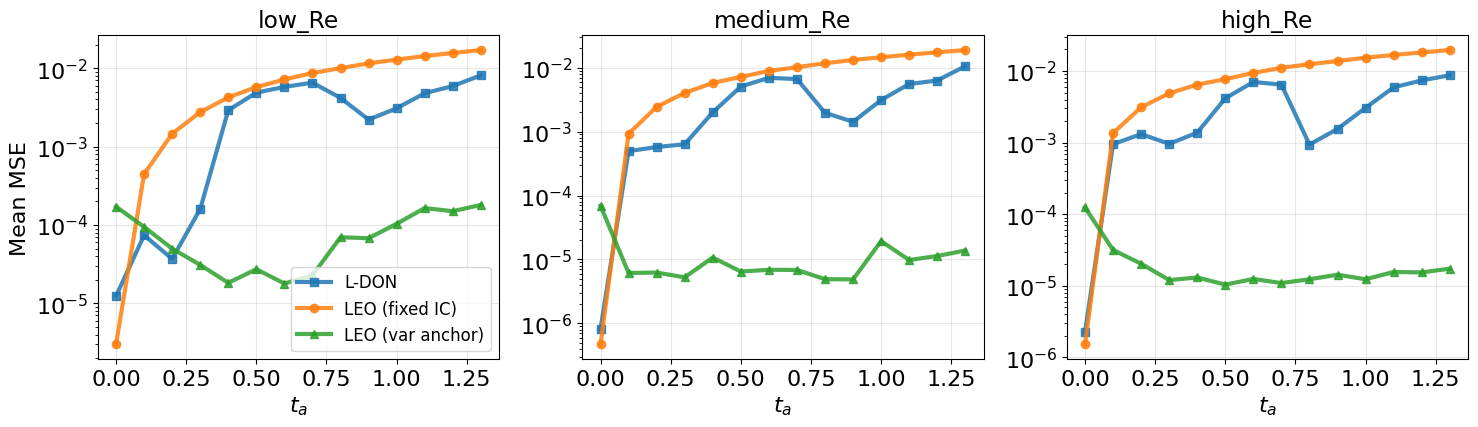


SUMMARY STATISTICS (VARYING ANCHOR STATES)

LOW_RE REGION:
  L-DON:               3.48e-03
  LEO (fixed IC):   8.01e-03
  LEO (var anchor): 8.35e-05
  LEO vs L-DON improvement: -130.1%
  LEO   vs L-DON improvement: +97.6%
  LEO   vs LEO-Fixed improvement: +99.0%

MEDIUM_RE REGION:
  L-DON:               3.65e-03
  LEO (fixed IC):   9.34e-03
  LEO (var anchor): 1.30e-05
  LEO vs L-DON improvement: -155.7%
  LEO   vs L-DON improvement: +99.6%
  LEO   vs LEO-Fixed improvement: +99.9%

HIGH_RE REGION:
  L-DON:               3.56e-03
  LEO (fixed IC):   1.00e-02
  LEO (var anchor): 2.30e-05
  LEO vs L-DON improvement: -181.2%
  LEO   vs L-DON improvement: +99.4%
  LEO   vs LEO-Fixed improvement: +99.8%


In [40]:
# Choose anchor times
t_init_list = np.arange(0.0, 1.4, 0.1)
results = evaluate_models_across_time_intervals(t_init_list, num_samples_per_t=250)

print("Plotting results...")
plot_results_across_regions(results, save_path='temporal_generalization_comparison.png')

print_temporal_generalization_summary(results)

In [41]:
def count_parameters(model):
    """Count total trainable parameters in a model."""
    if model is None or not hasattr(model, "parameters"):
        return 0
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_simple_parameter_summary():
    """Simple parameter summary for quick overview (L-DON + 2 Evo models)."""
    print("=" * 60)
    print("MODEL PARAMETER SUMMARY")
    print("=" * 60)

    # L-DON components
    ldon_params = 0
    ldon_components = [
        ("Encoder", enc),
        ("Decoder", dec),
        ("Branch", branch),
        ("Trunk", trunk),
    ]

    print("\nL-DON Components:")
    for name, model in ldon_components:
        params = count_parameters(model)
        ldon_params += params
        print(f"  {name:12}: {params:>12,}")

    # forward_latent is a function
    print(f"  {'Forward':12}: {'0':>12}  (function)")
    print(f"  {'TOTAL':12}: {ldon_params:>12,}")

    
    # Evo-Op (fixed IC trained)
    print("\nEvo-Op (fixed IC trained):")
    evo_fixed_total = 0
    if 'evol_op_fixed' in globals() and evol_op_fixed is not None:
        evo_fixed_total = count_parameters(evol_op_fixed)
        print(f"  {'TOTAL':12}: {evo_fixed_total:>12,}")
    else:
        print("  Model not found (expected variable: evol_op_fixed)")


    # Evo-Op (varying anchor trained)
    print("\nEvo-Op (varying anchor trained):")
    evo_var_total = 0
    if 'evol_op_var' in globals() and evol_op_var is not None:
        evo_var_total = count_parameters(evol_op_var)
        print(f"  {'TOTAL':12}: {evo_var_total:>12,}")
    else:
        print("  Model not found (expected variable: evol_op_var)")

    # Comparisons
    print("\nComparison:")
    print(f"  {'L-DON':24}: {ldon_params:>12,}")
    print(f"  {'Evo-Op (fixed IC)':24}: {evo_fixed_total:>12,}")
    print(f"  {'Evo-Op (var anchor)':24}: {evo_var_total:>12,}")

    if ldon_params > 0 and evo_fixed_total > 0:
        print(f"  {'Fixed / L-DON ratio':24}: {evo_fixed_total / ldon_params:.2f}x")
    if ldon_params > 0 and evo_var_total > 0:
        print(f"  {'Var / L-DON ratio':24}: {evo_var_total / ldon_params:.2f}x")
    if evo_fixed_total > 0 and evo_var_total > 0:
        print(f"  {'Var / Fixed ratio':24}: {evo_var_total / evo_fixed_total:.2f}x")


# Run it
print_simple_parameter_summary()

MODEL PARAMETER SUMMARY

L-DON Components:
  Encoder     :      242,658
  Decoder     :      242,784
  Branch      :       41,632
  Trunk       :       13,532
  Forward     :            0  (function)
  TOTAL       :      540,606

Evo-Op (fixed IC trained):
  TOTAL       :      486,198

Evo-Op (varying anchor trained):
  TOTAL       :      486,198

Comparison:
  L-DON                   :      540,606
  Evo-Op (fixed IC)       :      486,198
  Evo-Op (var anchor)     :      486,198
  Fixed / L-DON ratio     : 0.90x
  Var / L-DON ratio       : 0.90x
  Var / Fixed ratio       : 1.00x
